In [1]:
import os
import shutil
from typing import Union

import sys
sys.path.append("/Users/jocareher/Library/CloudStorage/OneDrive-Personal/Educación/PhD_UPF_2023/face_detection/scripts/")
import data_setup, visualization

## Step 1: split json files, create .txt files, and copy corresponding images

In [2]:
# Create individual json files from master json file (babyset)
metadata = "/Users/jocareher/Downloads/babyset.json"
output_dir = "/Users/jocareher/Downloads/new_dataset/babyset_files"
data_setup.process_and_save_json(metadata, output_dir)

# Create individual json files from master json file (bcn_babies)
metadata_bcn = "/Users/jocareher/Downloads/extra_faces.json"
output_dir_bcn = "/Users/jocareher/Downloads/new_dataset/extrafaces_files"
data_setup.process_and_save_json(metadata_bcn, output_dir_bcn)

In [ ]:
# Delete images without a corresponding json files
images_dir = "/Users/jocareher/Downloads/under_construction_dataset/Hospital_del_Mar"
json_folder = "/Users/jocareher/Downloads/new_dataset/bcn_babies_json_files"
data_setup.delete_json_without_jpg(json_folder = json_folder,
                                   images_folder = images_dir)

In [3]:
# Create .txt file for each image (bcn_babies)
json_files_bcn = "/Users/jocareher/Downloads/new_dataset/babyset_files"
output_dir_bcn = "/Users/jocareher/Downloads/new_dataset/babyset_files_txt"
class_list = ["3/4_left_sideview", "3/4_rigth_sideview", "Frontal", "Left_sideview", "Right_sideview"]
original_size = True
output_format = "normalized_original"
angle_unit = "radians"
data_setup.convert_annotations_to_yolo_obb(json_folder_path=json_files_bcn,
                                           output_folder_path=output_dir_bcn,
                                           class_list=class_list,
                                           original_size=original_size,
                                           output_format=output_format,
                                           angle_unit=angle_unit)

# Create .txt file for each image (bcn_babies)
json_files_extra = "/Users/jocareher/Downloads/new_dataset/extrafaces_files"
output_dir_extra = "/Users/jocareher/Downloads/new_dataset/extra_files_txt"
class_list = ["3/4_left_sideview", "3/4_rigth_sideview", "Frontal", "Left_sideview", "Right_sideview"]
original_size = True
output_format = "normalized_original"
angle_unit = "radians"
data_setup.convert_annotations_to_yolo_obb(json_folder_path=json_files_extra,
                                           output_folder_path=output_dir_extra,
                                           class_list=class_list,
                                           original_size=original_size,
                                           output_format=output_format,
                                           angle_unit=angle_unit)

In [ ]:
# Create .txt file for each image (bcn_babies)
json_files_bcn = "/Users/jocareher/Downloads/bcn_babies_json_files"
output_dir_bcn = "/Users/jocareher/Downloads/all_labels_bcn_babies"
class_list = ["3/4_left_sideview", "3/4_rigth_sideview", "Frontal", "Left_sideview", "Right_sideview"]
original_size = True
output_format = "normalized_original"
angle_unit = "radians"
data_setup.convert_annotations_to_yolo_obb(json_folder_path=json_files_bcn,
                                           output_folder_path=output_dir_bcn,
                                           class_list=class_list,
                                           original_size=original_size,
                                           output_format=output_format,
                                           angle_unit=angle_unit)

In [15]:
# Create .txt file for each image (extra_faces)
json_files_extra = "/Users/jocareher/Downloads/new_dataset/extra_faces_json_files"
output_dir_extra = "/Users/jocareher/Downloads/new_dataset/all_labels_extra_faces"
class_list = ["3/4_left_sideview", "3/4_rigth_sideview", "Frontal", "Left_sideview", "Right_sideview"]
original_size = True
output_format = "normalized_original"
data_setup.convert_annotations_to_yolo_obb(json_folder_path=json_files_extra,
                                           output_folder_path=output_dir_extra,
                                           class_list=class_list,
                                           original_size=original_size,
                                           output_format=output_format)

In [4]:
def copy_corresponding_images(labels_dir: str, img_dir: str, output_dir: str) -> None:
    """
    Copies images corresponding to .txt files from one folder to another.
    
    This function scans through a directory for .txt files and another directory for image files (.jpg, .JPG).
    For each .txt file, it finds a corresponding image file with the same base name and copies it to a specified
    destination folder.
    
    Args:
        - labels_dir (str): The path to the directory containing .txt files.
        - img_dir (str): The path to the directory containing image files (.jpg, .JPG).
        - output_dir (str): The destination directory path where corresponding images will be copied.
    
    Returns:
    None
    """
    # Ensure the destination directory exists, create if it doesn't
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Loop through each file in the .txt directory
    for file in os.listdir(labels_dir):
        if file.endswith(".txt"):
            # Extract the base name without extension
            base_name = os.path.splitext(file)[0]
            
            # Look for corresponding .jpg or .JPG files in the image directory
            for img_ext in ['.jpg', '.JPG']:
                img_path = os.path.join(img_dir, base_name + img_ext)
                if os.path.exists(img_path):
                    # If found, copy the image to the destination directory
                    shutil.copy(img_path, output_dir)
                    print(f"Copied {img_path} to {output_dir}")
                    break  # Stop looking for other extensions once the file is found and copied

In [5]:
# Copy images for each corresponding .txt files (babyset)
labels_dir = "/Users/jocareher/Downloads/new_dataset/babyset_files_txt"
img_dir = "/Users/jocareher/Downloads/under_construction_dataset/Baby_Face"
output_dir = "/Users/jocareher/Downloads/new_dataset/all_images_babyset"
copy_corresponding_images(labels_dir=labels_dir,
                          img_dir=img_dir,
                          output_dir=output_dir)

Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_3703.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_5372.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_1114.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_965.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_7565.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_7203.jpg to /Users/jocareher/Downloads/new_dataset/all_images_babyset
Copied /Users/jocareher/Downloads/under_construction_dataset/Baby_Face/face_img_8130.jpg to /Users/jo

In [6]:
# Copy images for each corresponding .txt files (extra_faces)
labels_dir_extra = "/Users/jocareher/Downloads/new_dataset/extra_files_txt"
img_dir_extra = "/Users/jocareher/Downloads/under_construction_dataset/extra_faces"
output_dir_extra = "/Users/jocareher/Downloads/new_dataset/all_images_extra_faces"
copy_corresponding_images(labels_dir=labels_dir_extra,
                          img_dir=img_dir_extra,
                          output_dir=output_dir_extra)

Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_13.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_07.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_06.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_12.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_38.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_dataset/extra_faces/extra_faces_04.jpg to /Users/jocareher/Downloads/new_dataset/all_images_extra_faces
Copied /Users/jocareher/Downloads/under_construction_datas

## Step 2: Generate flipped images

In [7]:
# Create flipped images from split sets (train, val, test)
data_setup.generate_horizontal_flipped_images("/Users/jocareher/Downloads/new_dataset/final_babyset_split_per_set/test", "/Users/jocareher/Downloads/new_dataset/images_per_dataset_test")

All images and labels have been flipped and saved in /Users/jocareher/Downloads/new_dataset/images_per_dataset_test


## Step 3: Create train, val and test sets

In [7]:
# Split dataset into train, val and test set
data_setup.distribute_dataset("/Users/jocareher/Downloads/new_dataset/obbabyface_v2", "/Users/jocareher/Downloads/new_dataset/final_babyset_split_per_set")

In [9]:
# Count how many annotations are per labels (without flips)
data_setup.count_labels_per_class_and_set("/Users/jocareher/Downloads/new_dataset/final_babyset_split_per_set")

Label count for the train set:
  3/4_left_sideview: 1827
  3/4_right_sideview: 1613
  Frontal: 3092
  Left_sideview: 514
  Right_sideview: 518

Label count for the val set:
  3/4_left_sideview: 238
  3/4_right_sideview: 234
  Frontal: 356
  Left_sideview: 62
  Right_sideview: 62

Label count for the test set:
  3/4_left_sideview: 221
  3/4_right_sideview: 169
  Frontal: 435
  Left_sideview: 45
  Right_sideview: 61



In [8]:
# Count how many annotations are per labels (flips per set)
data_setup.count_labels_per_class_and_set("/Users/jocareher/Downloads/new_dataset/final_babyset_split_per_set")

Label count for the train set:
  3/4_left_sideview: 3295
  3/4_right_sideview: 3265
  Frontal: 3092
  Left_sideview: 981
  Right_sideview: 980

Label count for the val set:
  3/4_left_sideview: 441
  3/4_right_sideview: 451
  Frontal: 356
  Left_sideview: 122
  Right_sideview: 118

Label count for the test set:
  3/4_left_sideview: 375
  3/4_right_sideview: 376
  Frontal: 435
  Left_sideview: 102
  Right_sideview: 104



# Step 3: Visualize the new annotations on the images

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
## NEED TO CHECK THIS FUNCTION
def plot_images_with_labels_and_obboxes(
    root_dir: str,
    output_dir: str = None,
    save_images: bool = True,
    display_images: bool = False,
    num_images_to_display: int = 4,
    line_thickness: int = 5,
    font_size: int = 14
):
    """
    Draws OBBs on images, highlighting the first edge (x1,y1 → x2,y2) in a different color.
    Assumes coordinates are normalized (0–1).
    """
    

    images_dir = os.path.join(root_dir, "images")
    labels_dir = os.path.join(root_dir, "labels")
    displayed_images = []

    if save_images and output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for image_name in os.listdir(images_dir):
        image_path = os.path.join(images_dir, image_name)
        image = Image.open(image_path)
        width, height = image.size

        label_path = os.path.join(labels_dir, os.path.splitext(image_name)[0] + ".txt")
        if os.path.exists(label_path):
            with open(label_path, "r") as file:
                lines = file.readlines()

            if display_images or save_images:
                fig, ax = plt.subplots()
                ax.imshow(image)
                ax.axis("off")

            for line in lines:
                class_index, *values = line.strip().split()
                values = list(map(float, values))
                coords = values[:8]  # x1 y1 x2 y2 x3 y3 x4 y4
                # angle = values[8]  # optional if you want to use it later

                # Convert normalized coordinates to absolute pixel positions
                abs_coords = [(coords[i] * width, coords[i + 1] * height) for i in range(0, 8, 2)]

                if display_images or save_images:
                    # Draw the full OBB in red
                    polygon = patches.Polygon(
                        abs_coords, closed=True, linewidth=line_thickness,
                        edgecolor="red", facecolor="none"
                    )
                    ax.add_patch(polygon)

                    # Highlight the edge (x1,y1) → (x2,y2) in blue
                    ax.plot(
                        [abs_coords[0][0], abs_coords[1][0]],
                        [abs_coords[0][1], abs_coords[1][1]],
                        color="blue",
                        linewidth=line_thickness
                    )

                    # Draw class label
                    ax.text(
                        abs_coords[0][0], abs_coords[0][1],
                        class_index, verticalalignment="top", color="green",
                        fontsize=font_size, weight="bold"
                    )

            # Save the processed image if requested
            if save_images and output_dir:
                output_image_path = os.path.join(output_dir, image_name)
                fig.savefig(output_image_path, bbox_inches="tight", pad_inches=0)
                plt.close(fig)

            if display_images:
                displayed_images.append(image_path)

    # Display random images in a grid
    if display_images and displayed_images:
        images_to_display = random.sample(displayed_images, min(num_images_to_display, len(displayed_images)))
        rows, cols = determine_grid_size(len(images_to_display))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
        for ax, img_path in zip(axes.ravel(), images_to_display):
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(os.path.basename(img_path))
        for ax in axes.ravel()[len(images_to_display):]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    if save_images and output_dir:
        print(f"All images have been processed and saved in {output_dir}")


def determine_grid_size(num_images: int) -> tuple:
    """
    Determines the number of rows and columns for the grid based on the number of images to display.
    """
    cols = int(np.ceil(np.sqrt(num_images)))
    rows = int(np.ceil(num_images / cols))
    return rows, cols

KeyboardInterrupt: 

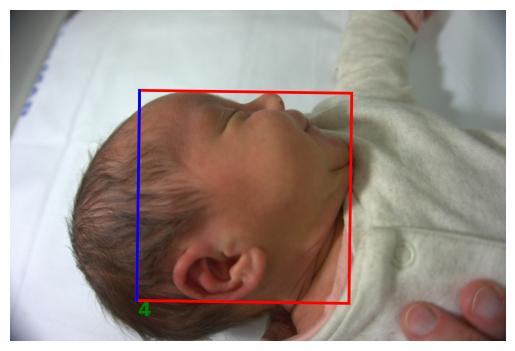

In [ ]:
plot_images_with_labels_and_obboxes("/Users/jocareher/Downloads/new_dataset/images_per_dataset", "/Users/jocareher/Downloads/new_testset_plots", True, True, 10, line_thickness=2)


In [58]:
data_setup.generate_horizontal_flipped_images("/Users/jocareher/Downloads/new_dataset/all_dataset_files", "/Users/jocareher/Downloads/new_dataset/")

All images and labels have been flipped and saved in /Users/jocareher/Downloads/new_dataset/


## Step 4: Copy .json correspoding to test set

In [72]:
data_setup.copy_corresponding_jsons("/Users/jocareher/Downloads/new_dataset/json_files_per_dataset/all_json_files","/Users/jocareher/Downloads/new_dataset/final_babyset_split_per_set/val/images", "/Users/jocareher/Downloads/new_dataset/train")

Copied: face_img_4650.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_8389.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_5554.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_2012.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_5387.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_5692.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_2507.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_8624.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_2679.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_4607.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_6285.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_4312.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_1813.json to /Users/jocareher/Downloads/new_dataset/train
Copied: face_img_4484.jso

In [73]:
# Create a new image per instance on test set
data_setup.split_annotations_and_create_new_files_per_face("/Users/jocareher/Downloads/new_dataset/test_set_for_rotating", "/Users/jocareher/Downloads/new_dataset/bechmark_test")

In [ ]:
data_setup.flip_rotation_in_json_file("/Users/jocareher/Downloads/new_dataset/test_set_for_rotating/json", "/Users/jocareher/Downloads/new_dataset/flipped_json")

In [78]:
#
data_setup.delete_json_without_jpg("/Users/jocareher/Downloads/new_dataset/flipped_json", "/Users/jocareher/Downloads/new_dataset/images_per_dataset/flipped_test_images")

Deleted: flip_face_img_371.json
Deleted: flip_face_img_1848.json
Deleted: flip_face_img_2767.json
Deleted: flip_face_img_7709.json
Deleted: flip_face_img_8278.json
Deleted: flip_face_img_7027.json
Deleted: flip_face_img_8297.json
Deleted: flip_face_img_6323.json
Deleted: flip_face_img_6765.json
Deleted: flip_face_img_7877.json
Deleted: flip_face_img_8147.json
Deleted: flip_face_img_449.json
Deleted: flip_face_img_7573.json
Deleted: flip_face_img_6948.json
Deleted: flip_face_img_6175.json
Deleted: flip_face_img_7733.json
Deleted: flip_face_img_7699.json
Deleted: flip_face_img_648.json
Deleted: flip_face_bcn_22.json
Deleted: flip_face_img_977.json
Deleted: flip_face_img_5870.json
Deleted: flip_face_img_4332.json
Deleted: flip_face_img_3048.json
Deleted: flip_face_img_2911.json
Deleted: flip_face_img_3316.json
Deleted: flip_face_img_7705.json
Deleted: flip_face_img_8223.json
Deleted: flip_face_img_5807.json
Deleted: flip_face_img_3087.json
Deleted: flip_face_img_2696.json
Deleted: flip_fa

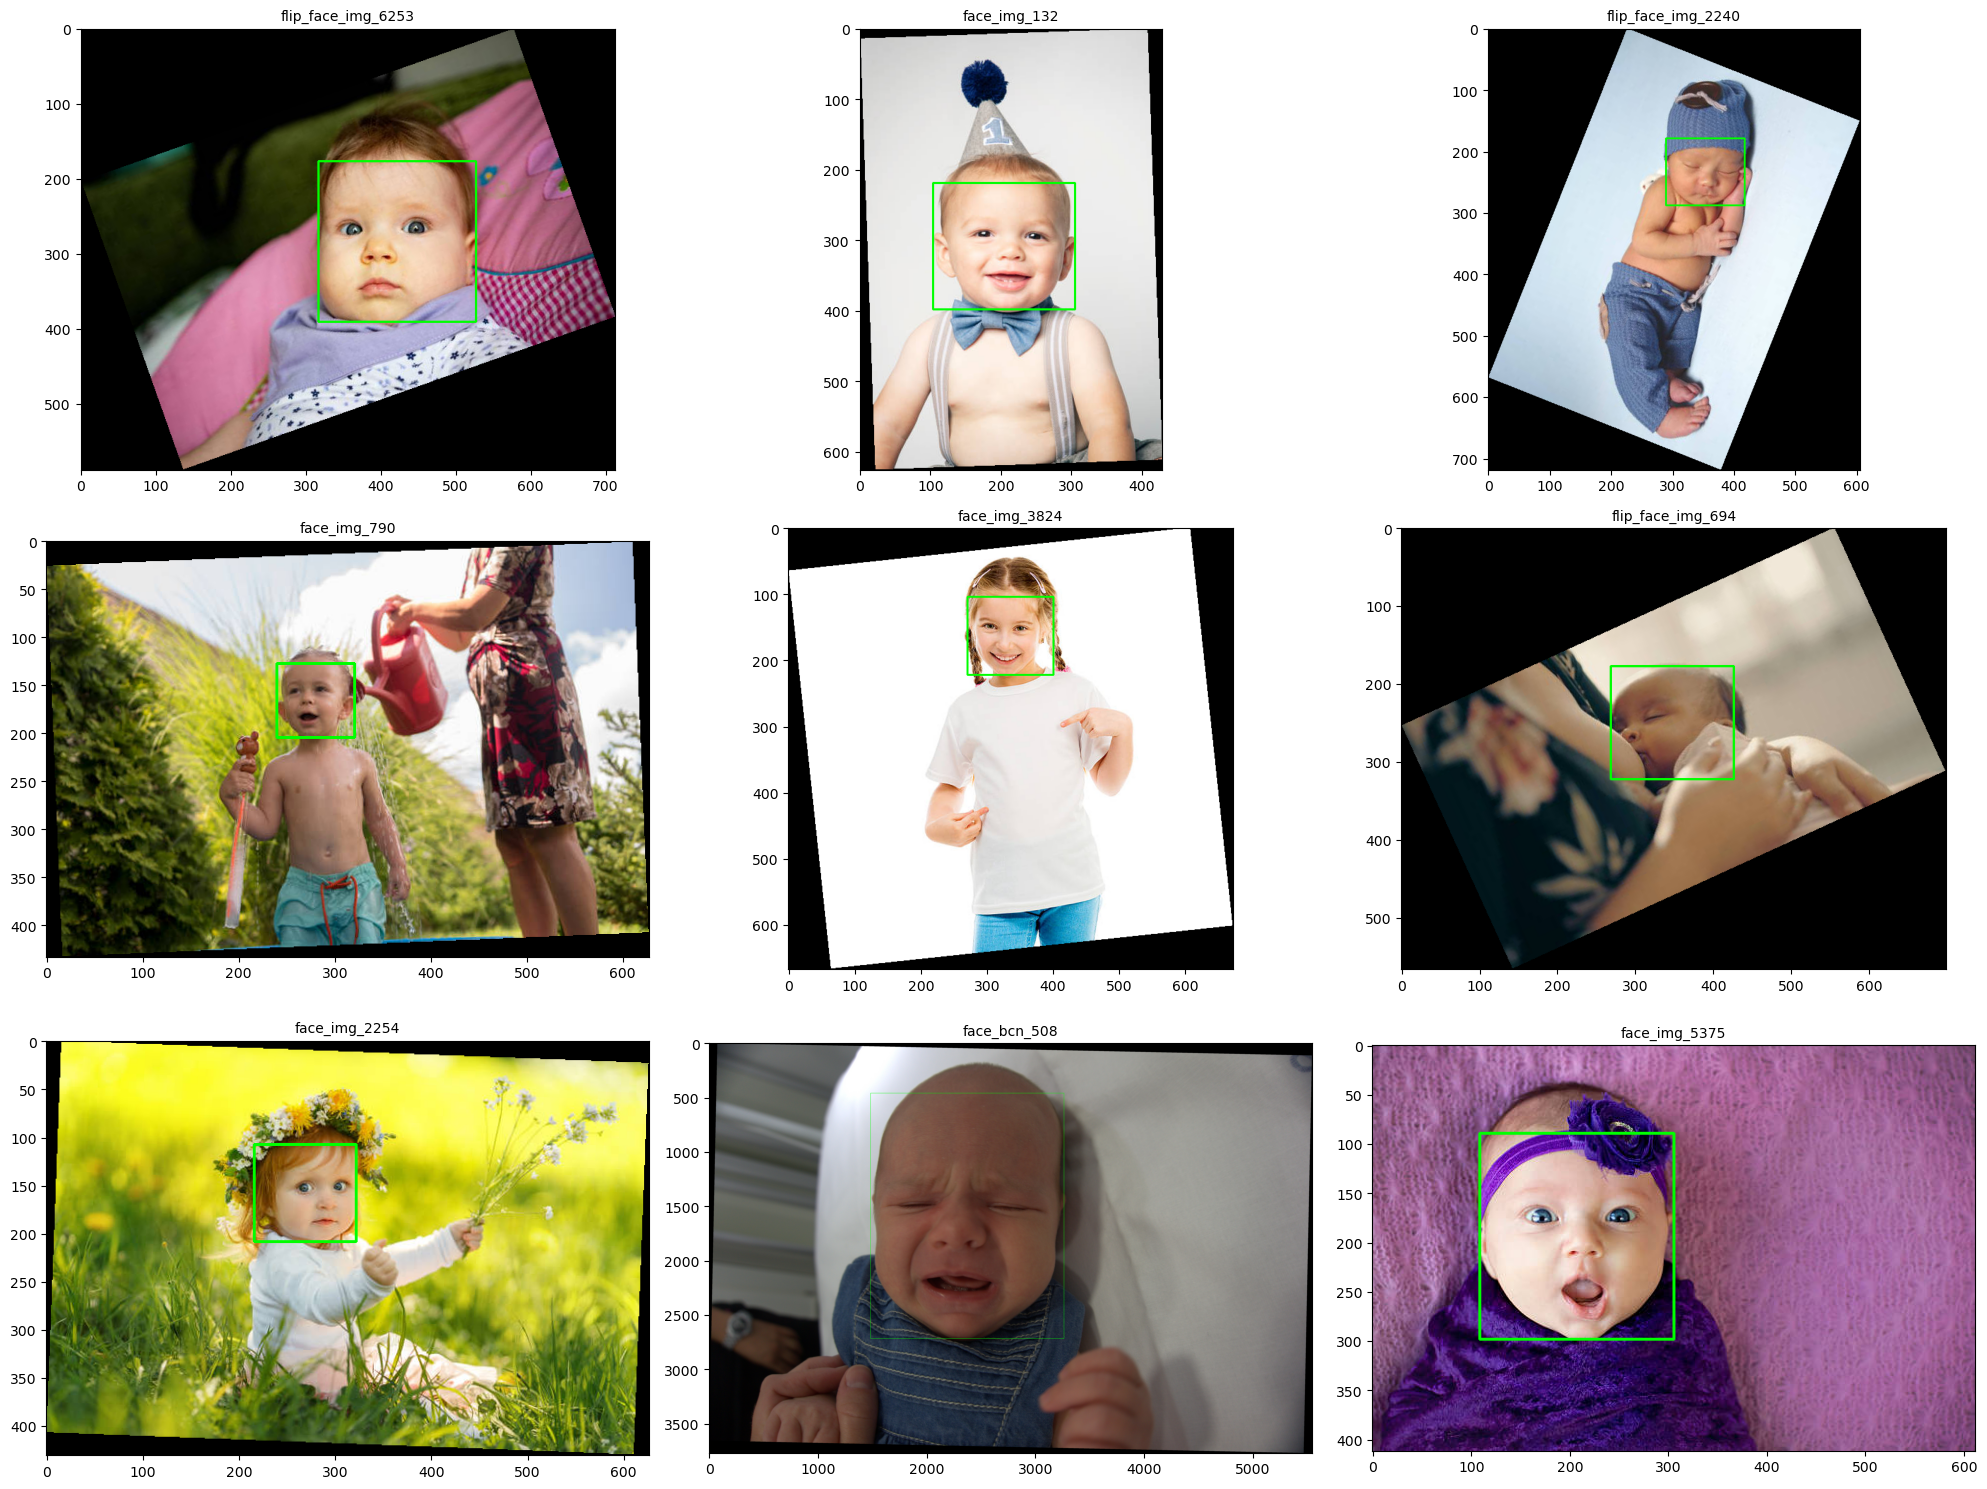

In [2]:
data_setup.visualize_rotated_images_and_aabboxes("/Users/jocareher/Downloads/new_dataset/bechmark_test", "/Users/jocareher/Downloads/benchmark_test_rotated_2", 9, True, False)

In [85]:
data_setup.update_bbox_class_index("/Users/jocareher/Downloads/flipped_labels")

In [72]:
import os
from PIL import Image, UnidentifiedImageError

def convert_coordinates(txt_content: str, img_width: int, img_height: int) -> tuple:
    """
    Converts normalized coordinates from a .txt file to absolute integer coordinates.

    Args:
        txt_content (str): Content of the text file containing normalized coordinates.
        img_width (int): Width of the image.
        img_height (int): Height of the image.

    Returns:
        tuple: A list of tuples containing class index and absolute coordinates. Each tuple may also contain a confidence score.
    """
    absolute_coordinates = []
    
    for line in txt_content.strip().split('\n'):
        parts = line.split()
        class_index = int(parts[0])
        
        # Convert normalized coordinates to absolute integers
        x1, y1 = int(float(parts[1]) * img_width), int(float(parts[2]) * img_height)
        x2, y2 = int(float(parts[3]) * img_width), int(float(parts[4]) * img_height)
        x3, y3 = int(float(parts[5]) * img_width), int(float(parts[6]) * img_height)
        x4, y4 = int(float(parts[7]) * img_width), int(float(parts[8]) * img_height)
        
        if len(parts) == 9:
            absolute_coordinates.append((class_index, x1, y1, x2, y2, x3, y3, x4, y4))
        else:
            score = float(parts[-1])
            absolute_coordinates.append((class_index, score, x1, y3, x2, y4, x3, y1+y3, x4, y2+y4))
    
    return absolute_coordinates

def convert_coordinates_from_normalize_to_absolute(root_path: str, save_path: str) -> None:
    """
    Converts normalized coordinates in .txt files to absolute integer coordinates and saves them.

    Args:
        root_path (str): Root directory containing 'labels' and 'images' subdirectories.
        save_path (str): Directory where the converted coordinate files will be saved.
    """
    # Create the save directory if it doesn't exist
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    labels_path = os.path.join(root_path, 'labels')
    images_path = os.path.join(root_path, 'images')

    # List all files in the labels directory
    for txt_file in os.listdir(labels_path):
        base_name = os.path.splitext(txt_file)[0]
        image_file = base_name + '.jpg'

        # Path to the image file
        image_path = os.path.join(images_path, image_file)

        try:
            # Load the image to get its dimensions
            image = Image.open(image_path)
            width, height = image.size

            # Read normalized coordinates from the .txt file
            with open(os.path.join(labels_path, txt_file), 'r') as file:
                txt_content = file.read()

            # Convert coordinates to absolute integers
            absolute_coordinates = convert_coordinates(txt_content, width, height)

            # Write the converted coordinates to a new .txt file in the save directory
            save_file_path = os.path.join(save_path, txt_file)
            with open(save_file_path, 'w') as file:
                for coords in absolute_coordinates:
                    line = []
                    for index, coord in enumerate(coords):
                        if index == 1 and isinstance(coord, float):  # Format the confidence score
                            line.append(f"{coord:.6f}")
                        else:
                            line.append(str(int(coord)))  # Convert other values to int
                    file.write(' '.join(line) + '\n')

        except UnidentifiedImageError:
            print(f"Error: Cannot identify image file '{image_path}'. Skipping this file.")
        except Exception as e:
            print(f"An error occurred while processing file '{image_path}': {e}")


In [73]:
convert_coordinates_from_normalize_to_absolute("/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/test", "/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/test/labels_abs")

Error: Cannot identify image file '/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/test/images/._face_img_239.jpg'. Skipping this file.


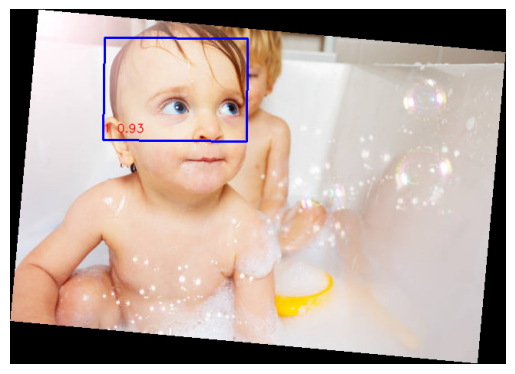

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_bboxes_from_normalized_file(image_path: str, bbox_file_path: str) -> None:
    """
    Dibuja bounding boxes en una imagen usando coordenadas normalizadas.

    Args:
        image_path (str): Ruta de la imagen.
        bbox_file_path (str): Ruta del archivo de bounding boxes con coordenadas normalizadas.
    """
    # Leer la imagen
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Verificar si la imagen se cargó correctamente
    if image is None:
        print("Error al cargar la imagen")
        return

    # Obtener las dimensiones de la imagen
    img_height, img_width, _ = image.shape

    # Leer las bounding boxes desde el archivo
    with open(bbox_file_path, 'r') as file:
        lines = file.readlines()

    # Dibujar cada bounding box en la imagen
    for line in lines:
        parts = line.strip().split()
        label = parts[0]
        normalized_coords = list(map(float, parts[1:-1]))
        score = float(parts[-1])

        # Convertir coordenadas normalizadas a absolutas
        abs_coords = []
        for i in range(0, len(normalized_coords), 2):
            abs_x = int(normalized_coords[i] * img_width)
            abs_y = int(normalized_coords[i + 1] * img_height)
            abs_coords.append((abs_x, abs_y))

        # Crear un array de puntos
        points = np.array(abs_coords, dtype=np.int32).reshape((-1, 1, 2))

        # Dibujar el polígono en la imagen
        cv2.polylines(image, [points], isClosed=True, color=(0, 0, 255), thickness=2)

        # Agregar el texto de la etiqueta y el score
        x, y = abs_coords[0]
        cv2.putText(image, f"{label} {score:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)

    # Mostrar la imagen con las bounding boxes dibujadas
    plt.imshow(image)
    plt.axis('off')  # Ocultar los ejes
    plt.show()

# Llamar a la función con los archivos proporcionados
draw_bboxes_from_normalized_file(image_path, '/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/labels/face_img_239.txt')


In [46]:
# Llamar a la función con las rutas correspondientes
convert_coordinates_from_normalize_to_absolute('/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/test', '/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/tests/abs')

In [11]:
def convert_bboxes_from_4_points_to_8_points(input_dir: str, output_dir: str, format: str = "detection", has_confidence_score: bool = True) -> None:
    """
    Converts bounding box format from the input directory and writes the converted format to the output directory.

    Args:
        input_dir (str): Directory containing the input .txt files with bounding box data.
        output_dir (str): Directory where the converted bounding box data will be saved.
        format (str): Format of the bounding boxes in the input files. Defaults to "detection".
        has_confidence_score (bool): Indicates whether the input bounding box data includes confidence scores. Defaults to True.
    """
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Process each txt file in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith('.txt') and not filename.startswith('.'):
            with open(os.path.join(input_dir, filename), 'r') as file:
                lines = file.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                
                if format == "detection":
                    if has_confidence_score:
                        # Parse with confidence score
                        confidence_score, x, y, x_plus_w, y_plus_h = map(float, parts)
                    else:
                        # Parse without confidence score
                        x, y, x_plus_w, y_plus_h = map(float, parts)
                        confidence_score = None
                else:
                    # Parse line and confidence score for other formats
                    l, x, y, w, h = map(float, parts)

                if format == "detection":
                    # Calculate corners for detection format
                    x1, y1 = x, y                   # Top-left corner
                    x2, y2 = x_plus_w, y            # Top-right corner
                    x3, y3 = x_plus_w, y_plus_h     # Bottom-right corner
                    x4, y4 = x, y_plus_h            # Bottom-left corner
                else:
                    # Calculate corners for other formats
                    x1, y1 = x, y                   # Top-left corner
                    x2, y2 = x + w, y               # Top-right corner
                    x3, y3 = x + w, y + h           # Bottom-right corner
                    x4, y4 = x, y + h               # Bottom-left corner

                # Create the new line based on the format and confidence score
                if format == "detection" and confidence_score is not None:
                    new_line = f"{confidence_score} {int(x1)} {int(y1)} {int(x2)} {int(y2)} {int(x3)} {int(y3)} {int(x4)} {int(y4)}"
                elif format == "detection" and confidence_score is None:
                    new_line = f"{int(x1)} {int(y1)} {int(x2)} {int(y2)} {int(x3)} {int(y3)} {int(x4)} {int(y4)}"
                else:
                    new_line = f"{int(l)} {int(x1)} {int(y1)} {int(x2)} {int(y2)} {int(x3)} {int(y3)} {int(x4)} {int(y4)}"

                new_lines.append(new_line)

            # Write the new lines to the output file
            with open(os.path.join(output_dir, filename), 'w') as file:
                for new_line in new_lines:
                    file.write(new_line + '\n')



convert_bboxes_from_4_points_to_8_points("/Volumes/JCRH_UPF/benchmark_test_split_rotated/4/labels", "/Volumes/JCRH_UPF/benchmark_test_split_rotated/4/labels_abs", "gt", False)


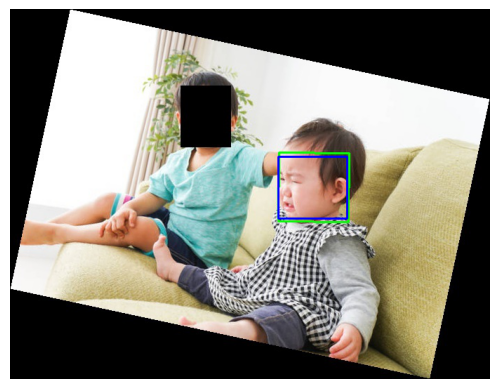

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_bbox_polygons_from_file(image_path: str, bbox_file_path: str) -> None:
    """
    Draws bounding boxes on an image from a given bounding box file.

    Args:
        image_path (str): Path to the image file.
        bbox_file_path (str): Path to the file containing bounding box coordinates.
    """
    # Read the original image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Check if the image was loaded successfully
    if image is None:
        print("Error loading the image")
        return

    # Read the bounding boxes from the file
    with open(bbox_file_path, 'r') as file:
        lines = file.readlines()

    # Draw each bounding box on the image
    for line in lines:
        parts = line.strip().split()
        # Assume that the last 8 numbers are the coordinates
        points = list(map(float, parts[-8:]))
        points = np.array(points, dtype=np.int32).reshape((-1, 1, 2))
        
        # Draw the polygon on the image
        cv2.polylines(image, [points], isClosed=True, color=(0, 0, 255), thickness=2)

    # Display the image with the drawn bounding boxes
    plt.imshow(image)
    plt.axis('off')  # Hide the axis
    plt.show()


# Ejemplo de uso:
draw_bbox_polygons_from_file("/Volumes/JCRH_UPF/yolo_preds/yolo_pred_3_4_left/manual_preds/images/extra_faces_33.jpg", "/Volumes/JCRH_UPF/benchmark_test_split_rotated/0/labels_abs/extra_faces_33.txt",)
